**Preliminari**

In [ ]:
from pathlib import Path

from model_utils import create_label_to_id_map, labels_to_bits, bits_to_labels, NAN_VALUE, get_multiple_choice_fields, get_binary_classification_fields, get_classification_fields


from IPython.display import clear_output

from huggingface_hub import login

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, DefaultDataCollator
from datasets import load_dataset, Dataset, DatasetDict

from constants import AnnotatedReport, Annotations

from classifiers import ReportExtractor
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from ast import literal_eval
import loop
import seaborn as sns
import matplotlib.pyplot as plt
from pprint import pprint
import math

In [17]:
plt.style.use('ggplot')

**Huggingface login**

**Parametri**

In [18]:
# Parameters
TRAIN_FILE_NAME = "train_split.csv"
VALIDATION_FILE_NAME = "validation_split.csv"
TEST_FILE_NAME = "test_split.csv"

**Load data**

In [19]:
# Carichiamo i nostri file csv
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
    'test': TEST_FILE_NAME  
}

paths = {
    split: Path('../data/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path)

train_data, validation_data, test_data = data['train'], data['validation'], data['test']
total_data = pd.concat([train_data, validation_data, test_data], ignore_index=True)

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")
print(f"{len(test_data) = }")

len(train_data) = 175
len(validation_data) = 43
len(test_data) = 57


In [20]:
mc_fields = get_multiple_choice_fields(Annotations)
cl_fields = get_classification_fields(Annotations)
bc_fields = get_binary_classification_fields(Annotations)
for field in train_data.columns:
    if field not in mc_fields + cl_fields + bc_fields:
        print(f"Field '{field}' not in any known annotation fields.")

Field 'report_text' not in any known annotation fields.
Field 'profile' not in any known annotation fields.
Field 'ore_inizio' not in any known annotation fields.
Field 'ore_fine' not in any known annotation fields.
Field 'spessore_parietale' not in any known annotation fields.
Field 'estensione_cranio_caudale' not in any known annotation fields.
Field 'distanza_oai' not in any known annotation fields.
Field 'numero_linfonodi_non_conosciuto' not in any known annotation fields.
Field 'linfonodi_sospetti' not in any known annotation fields.
Field 'numero_depositi' not in any known annotation fields.
Field 'split' not in any known annotation fields.


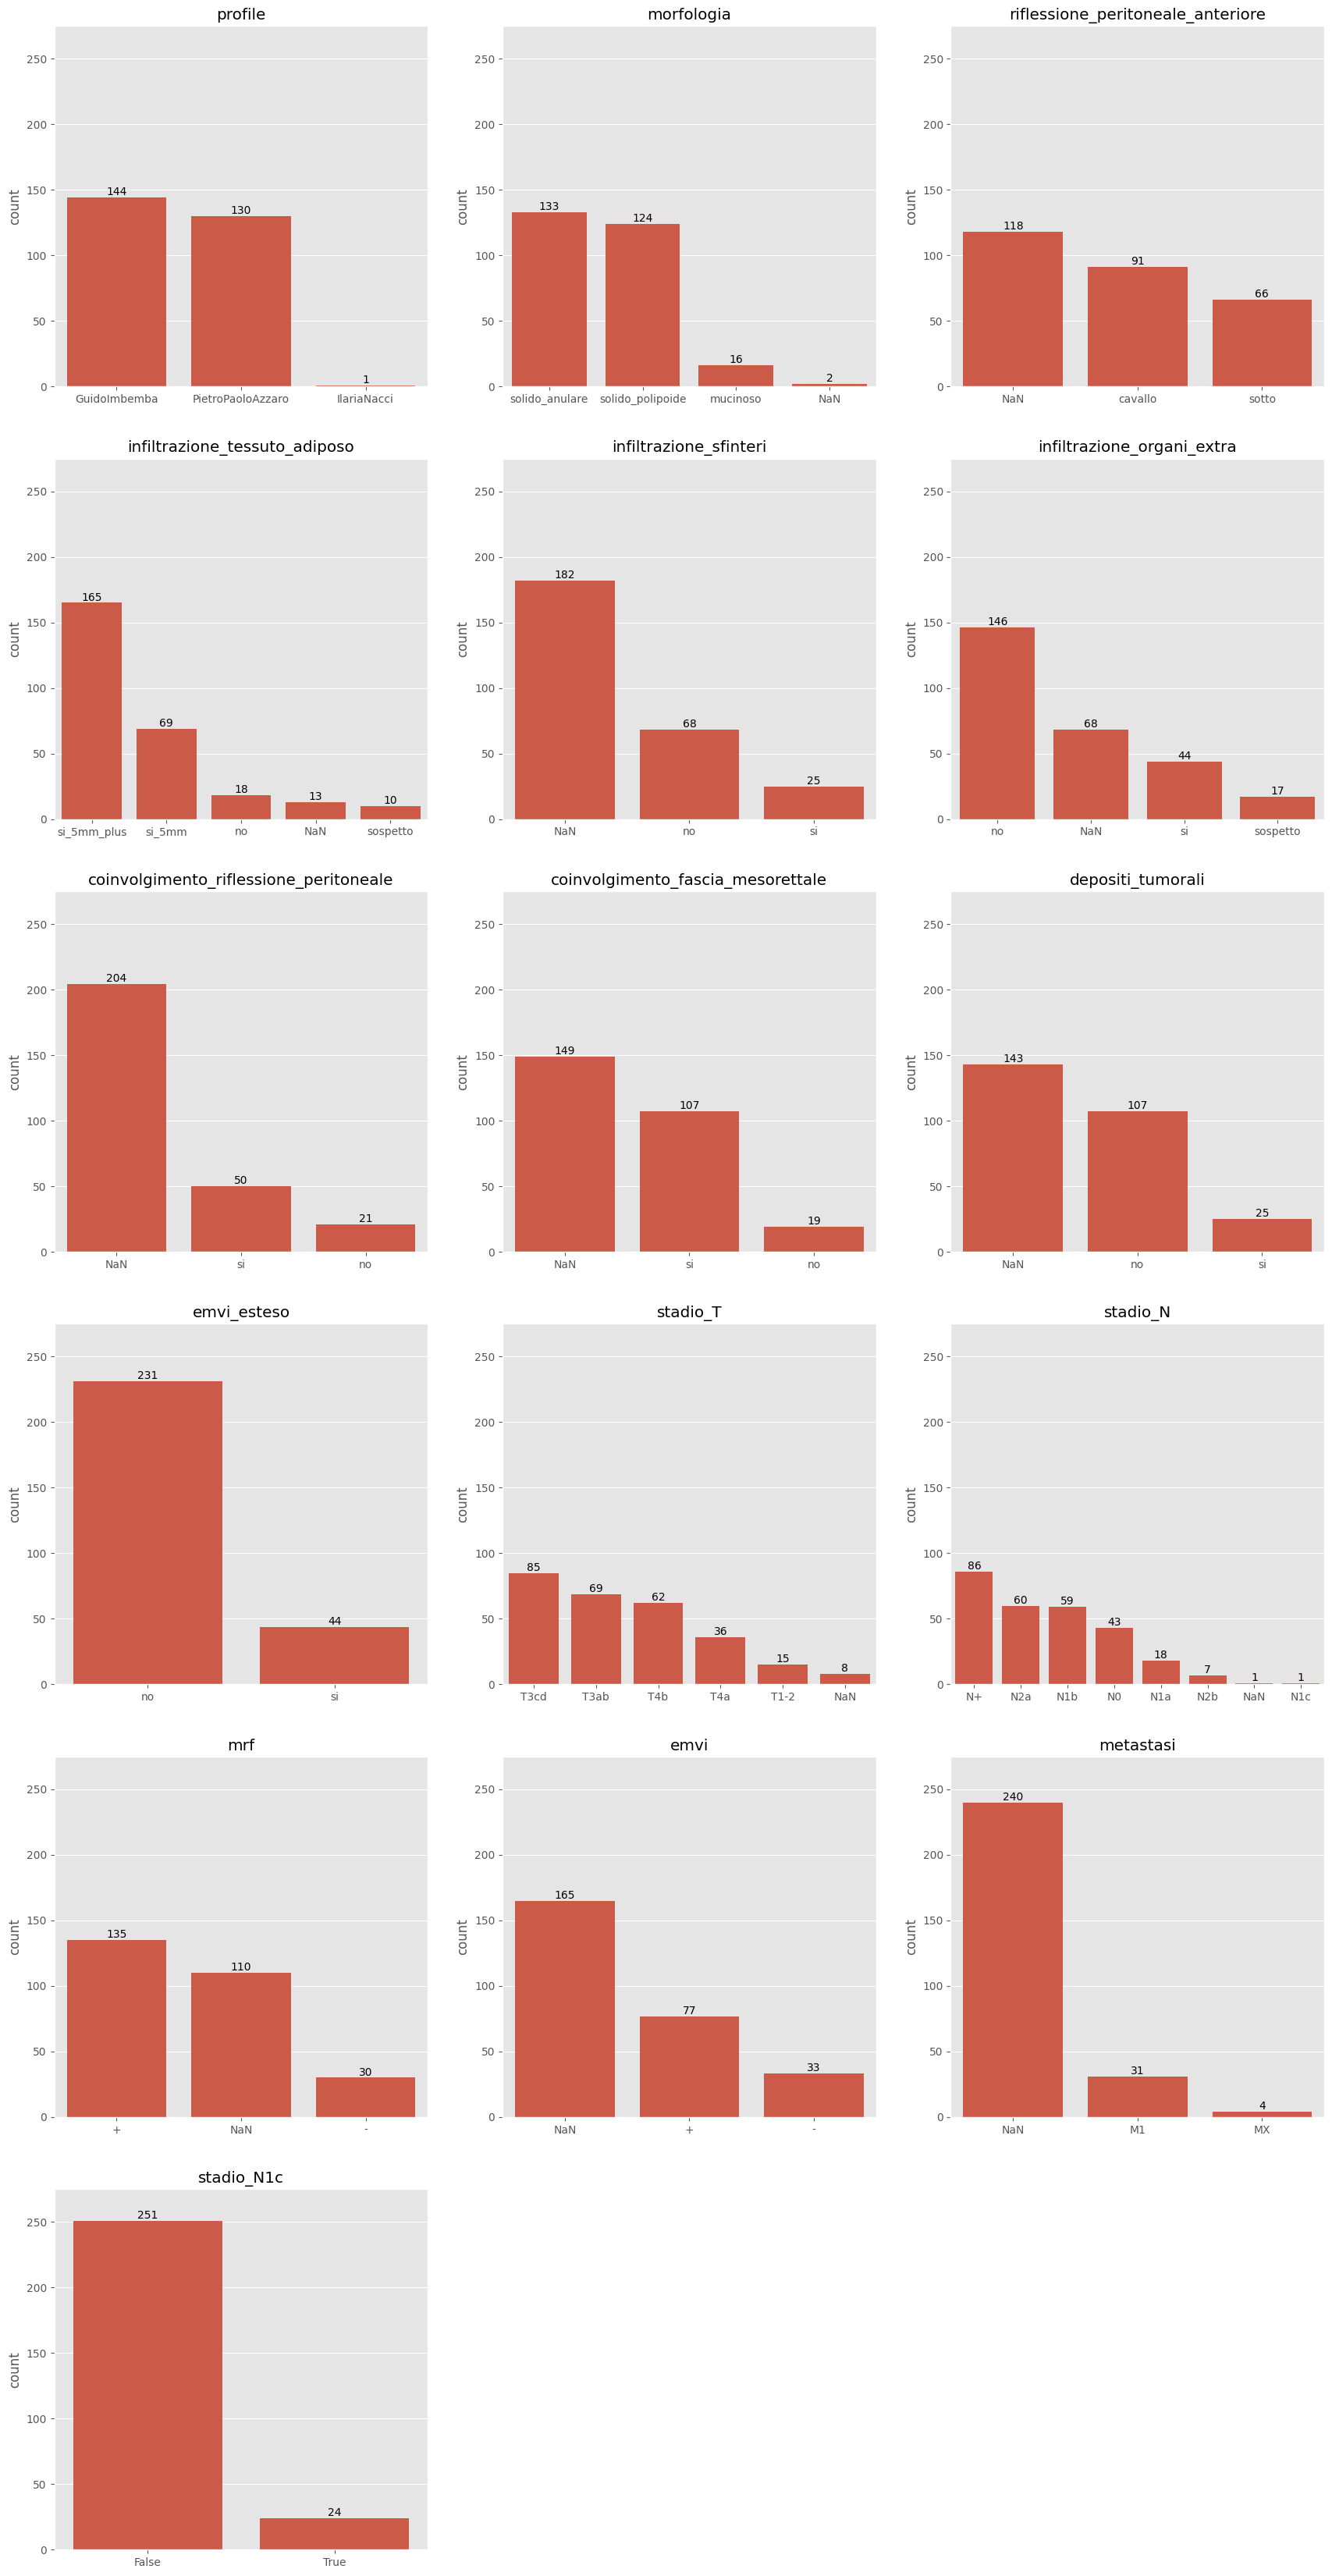

In [32]:
fields = ['profile'] + cl_fields + bc_fields
n_cols = 3
n_rows = math.ceil(len(fields) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 7*n_rows))
axes = axes.reshape(n_rows, n_cols)

df = []
for i, field in enumerate(fields):
    # PLot counts
    r = i // n_cols
    c = i % n_cols
    ax = axes[r, c]
    sns.countplot(x=field, data=total_data.fillna('NaN'),
                  #ax=ax, order=total_data.fillna('NaN')[field].value_counts().index, hue='profile')
                  ax=ax, order=total_data.fillna('NaN')[field].value_counts().index)
    ax.set_title(field)
    ax.set_xlabel("")
    ax.set_ylim(0, total_data.shape[0])
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

for idx in range(len(fields), n_rows*n_cols):
    r = idx // n_cols
    c = idx % n_cols
    axes[r, c].axis("off")

plt.show()

Si osserva che la quantità di referti annotati dai due annotatori (Guido e Pietropaolo) è simile, con un numero leggermente meggiore per Guido. Per questo, ci aspettiamo che anche per gli altri campi la distribuzione sia simile. Questo non accade per i seguenti campi:
- morfologia (solido anulare e solido polipoide)
- infiltrazione sfinteri
- infiltrazione organi extra
- coinvolgimento riflessione peritoneale
- coinvolgimento fascia mesorettale
- stadio N (N+ e N0)
- mrf
- emvi
- metastasi

Analizziamo ora solo i report annotati da Guido

modifiche da apportare:
- aggreghiamo MX a NaN per ottenere quindi solo due classi: M1 e NaN
- potremmo aggregare T4a con T4b
- si potrebbe aggregare lo stadio N in N+ e N0
- per MRF si potrebbe aggregare "-" con NaN
- aggreghiamo mucinoso con NaN e lo facciamo diventare altro
- in infiltrazione organi extra aggreghiamo no con NaN e si con sospetto
- coinvolgimento fascia mesorettale, aggreghiamo no con NaN
- coinvolgimento riflessione peritoneale: aggreghiamo no con nan
- per i depositi tumorali aggreghiamo no con NaN
- aggreghiamo no e NaN anche per infiltrazione sfinteri
- aggreghiamo - e NaN anche per mrf
- aggreghiamo - e NaN anche per emvi

In [36]:
pprint(total_data[total_data['infiltrazione_tessuto_adiposo'] == 'si_5mm_plus']['report_text'][0])

("RM ADDOME INFERIORE L'ESAME STATO ESEGUITO MEDIANTE SEQUENZE FSE,DWI, MIRATO "
 "ALLA STADIAZIONE LOCOREGIONALE DELLA NEOPLASIA RETTALE. L'ESAME STATO "
 'ESEGUITO IN DIFFICILI CONDIZIONI TECNICHE PER LA SCARSA COLLABORAZIONE DEL '
 'PAZIENTE E PER TALE MOTIVO IN ALCUNE SEQUENZE SONO PRESENTI ARTEFATTI DA '
 'MOVIMENTO. IN CORRISPONDENZA DEL RETTO MEDIO-BASSO PRESENTE GROSSOLANA '
 'FORMAZIONE AGGETTANTE CON EPICENTRO IN CORRISPONDENZA DELLA PARETE '
 'POSTEROLATERALE DESTRA CHE OCCUPA 3/4 DELLA CIRCONFERENZA DEL LUME CON '
 'ESTENSIONE CAUDO-CRANIALE DI CIRCA 6,8 CM DA CIRCA 4 CM DALLO SFINTERE ANALE '
 'INTERNO. LA NEOPLASIA INVIA DIGITAZIONI POLIPOIDI NEL MESORETTO DI DESTRA ED '
 'ANTERIORE CHE SEGUONO I VASI EMORROIDARI, ALCUNE DELLE QUALI ANTERIORMENTE '
 'RAGGIUNGONO LA FASCIA PERIRETTALE. TRE LINFONODI SOSPETTI NEL MESORETTO UNO '
 'DEI QUALI DI CIRCA 7 MM ADESO ALLA FASCIA PERIRETTALE. PICCOLO LINFONODO IN '
 'SEDE OTTURATORIA DESTRA. NUMEROSI, GROSSOLANI DIVERTICOLI CON AMP

In [39]:
pprint(total_data[total_data['infiltrazione_tessuto_adiposo'] == 'si_5mm_plus']['report_text'][3])

('RM ADDOME INFERIORE (S/C MDC) STUDIO RM CONDOTTO MEDIANTE SEQUENZE DWI, FSE '
 'E FSPGR-3D DISCO PRIMA E DOPO SOMMINISTRAZIONE EV DI MDC PARAMAGNETICO '
 '(PROHANCE 0.2 ML/KG), PREVIA DISTENSIONE DEL RETTO CON GEL. SI EVIDENZIA '
 'ISPESSIMENTO PARIETALE DEL RETTO MEDIO, CON MORFOLOGIA A SCODELLA '
 'VEROSIMILMENTE ULCERATA, CHE INTERESSA SUL VERSANTE POSTERO-LATERALE DESTRO '
 'OLTRE LA MET DELLA SUA CIRCONFERENZA, A CIRCA 7 CM DALLO SFINTERE ANALE '
 'INTERNO, E SI ESTENDE CRANIALMENTE PER CIRCA 3 CM; LA LESIONE, MODERATAMENTE '
 'INTENSA, PRESENTA RESTRIZIONE DELLA DIFFUSIONE PROTONICA E APPARE DOTATA DI '
 'SPICCATO CE. LA LESIONE PRESENTA SOTTILI SPICULE DISPOSTE A RAGGIERA NEL '
 'MESORETTO E UN GETTONE TISSUTALE SOLIDO DI 8 MM CHE INFILTRA IL MESORETTO IN '
 'SEDE POSTERIORE MEDIANA. LINFONODI SONO APPREZZABILI NEL MESORETTO LATERALE '
 'DI SINISTRA (DUE CON ASSE CORTO 5 MM - A MARGINI SPICULATI - E 4 MM) E DI '
 'DESTRA (ASSE CORTO 3 MM), ALMENO TRE IN SEDE EMORROIDARIA SUPER

In [48]:
pprint(total_data[total_data['infiltrazione_tessuto_adiposo'] == 'si_5mm']['report_text'][9])

('RM PELVI (CON MDC)\n'
 '\n'
 'ESAME ESEGUITO MEDIANTE SEQUENZE FSE, DWI E LAVA, PREVIA DISTENSIONE DEL '
 'RETTO CON GEL.\n'
 '\n'
 "SUBITO AL DI SOPRA DELL'ORIFIZIO ANALE INTERNO SI APPREZZA ASIMMETRICO "
 'ISPESSIMENTO PARIETALE DEL RETTO, IPERINTENSO IN T2, CHE SI ESTENDE IN SENSO '
 'CAUDO-CRANIALE PER CIRCA 3,5 CM. \n'
 'CRANIALMENTE, SUL VERSANTE ANTERIORE, SI APPREZZA FOCALE INTERRUZIONE '
 "DELL'IPOINTENSITÀ PARIETALE COME PER INIZIALE SCONFINAMENTO.\n"
 'DUE LINFONODI DEL DIAMETRO MASSIMO DI 4 MM SI APPREZZANO NEL MESORETTO DI '
 'SINISTRA ED UNO DI POCHI MM NEL MESORETTO DI DESTRA.\n'
 'UN LINFONODO ROTONDEGGIANTE DI 9 MM È EVIDENTE IN SEDE OTTURATORIA DESTRA.\n'
 'TRE MINUTI LINFONODI SI APPREZZANO IN SEDE EMORROIDARIA SUPERIORE.\n'
 'NON FALDE FLUIDE IN SEDE PELVICA.')


In [7]:
# Parameters
TRAIN_FILE_NAME = "train_split_guido.csv"
VALIDATION_FILE_NAME = "validation_split_guido.csv"
TEST_FILE_NAME = "test_split_guido.csv"

In [8]:
# Carichiamo i nostri file csv
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
    'test': TEST_FILE_NAME  
}

paths = {
    split: Path('../data/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path)

train_data, validation_data, test_data = data['train'], data['validation'], data['test']
total_data = pd.concat([train_data, validation_data, test_data], ignore_index=True)

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")
print(f"{len(test_data) = }")

len(train_data) = 116
len(validation_data) = 28
len(test_data) = 28


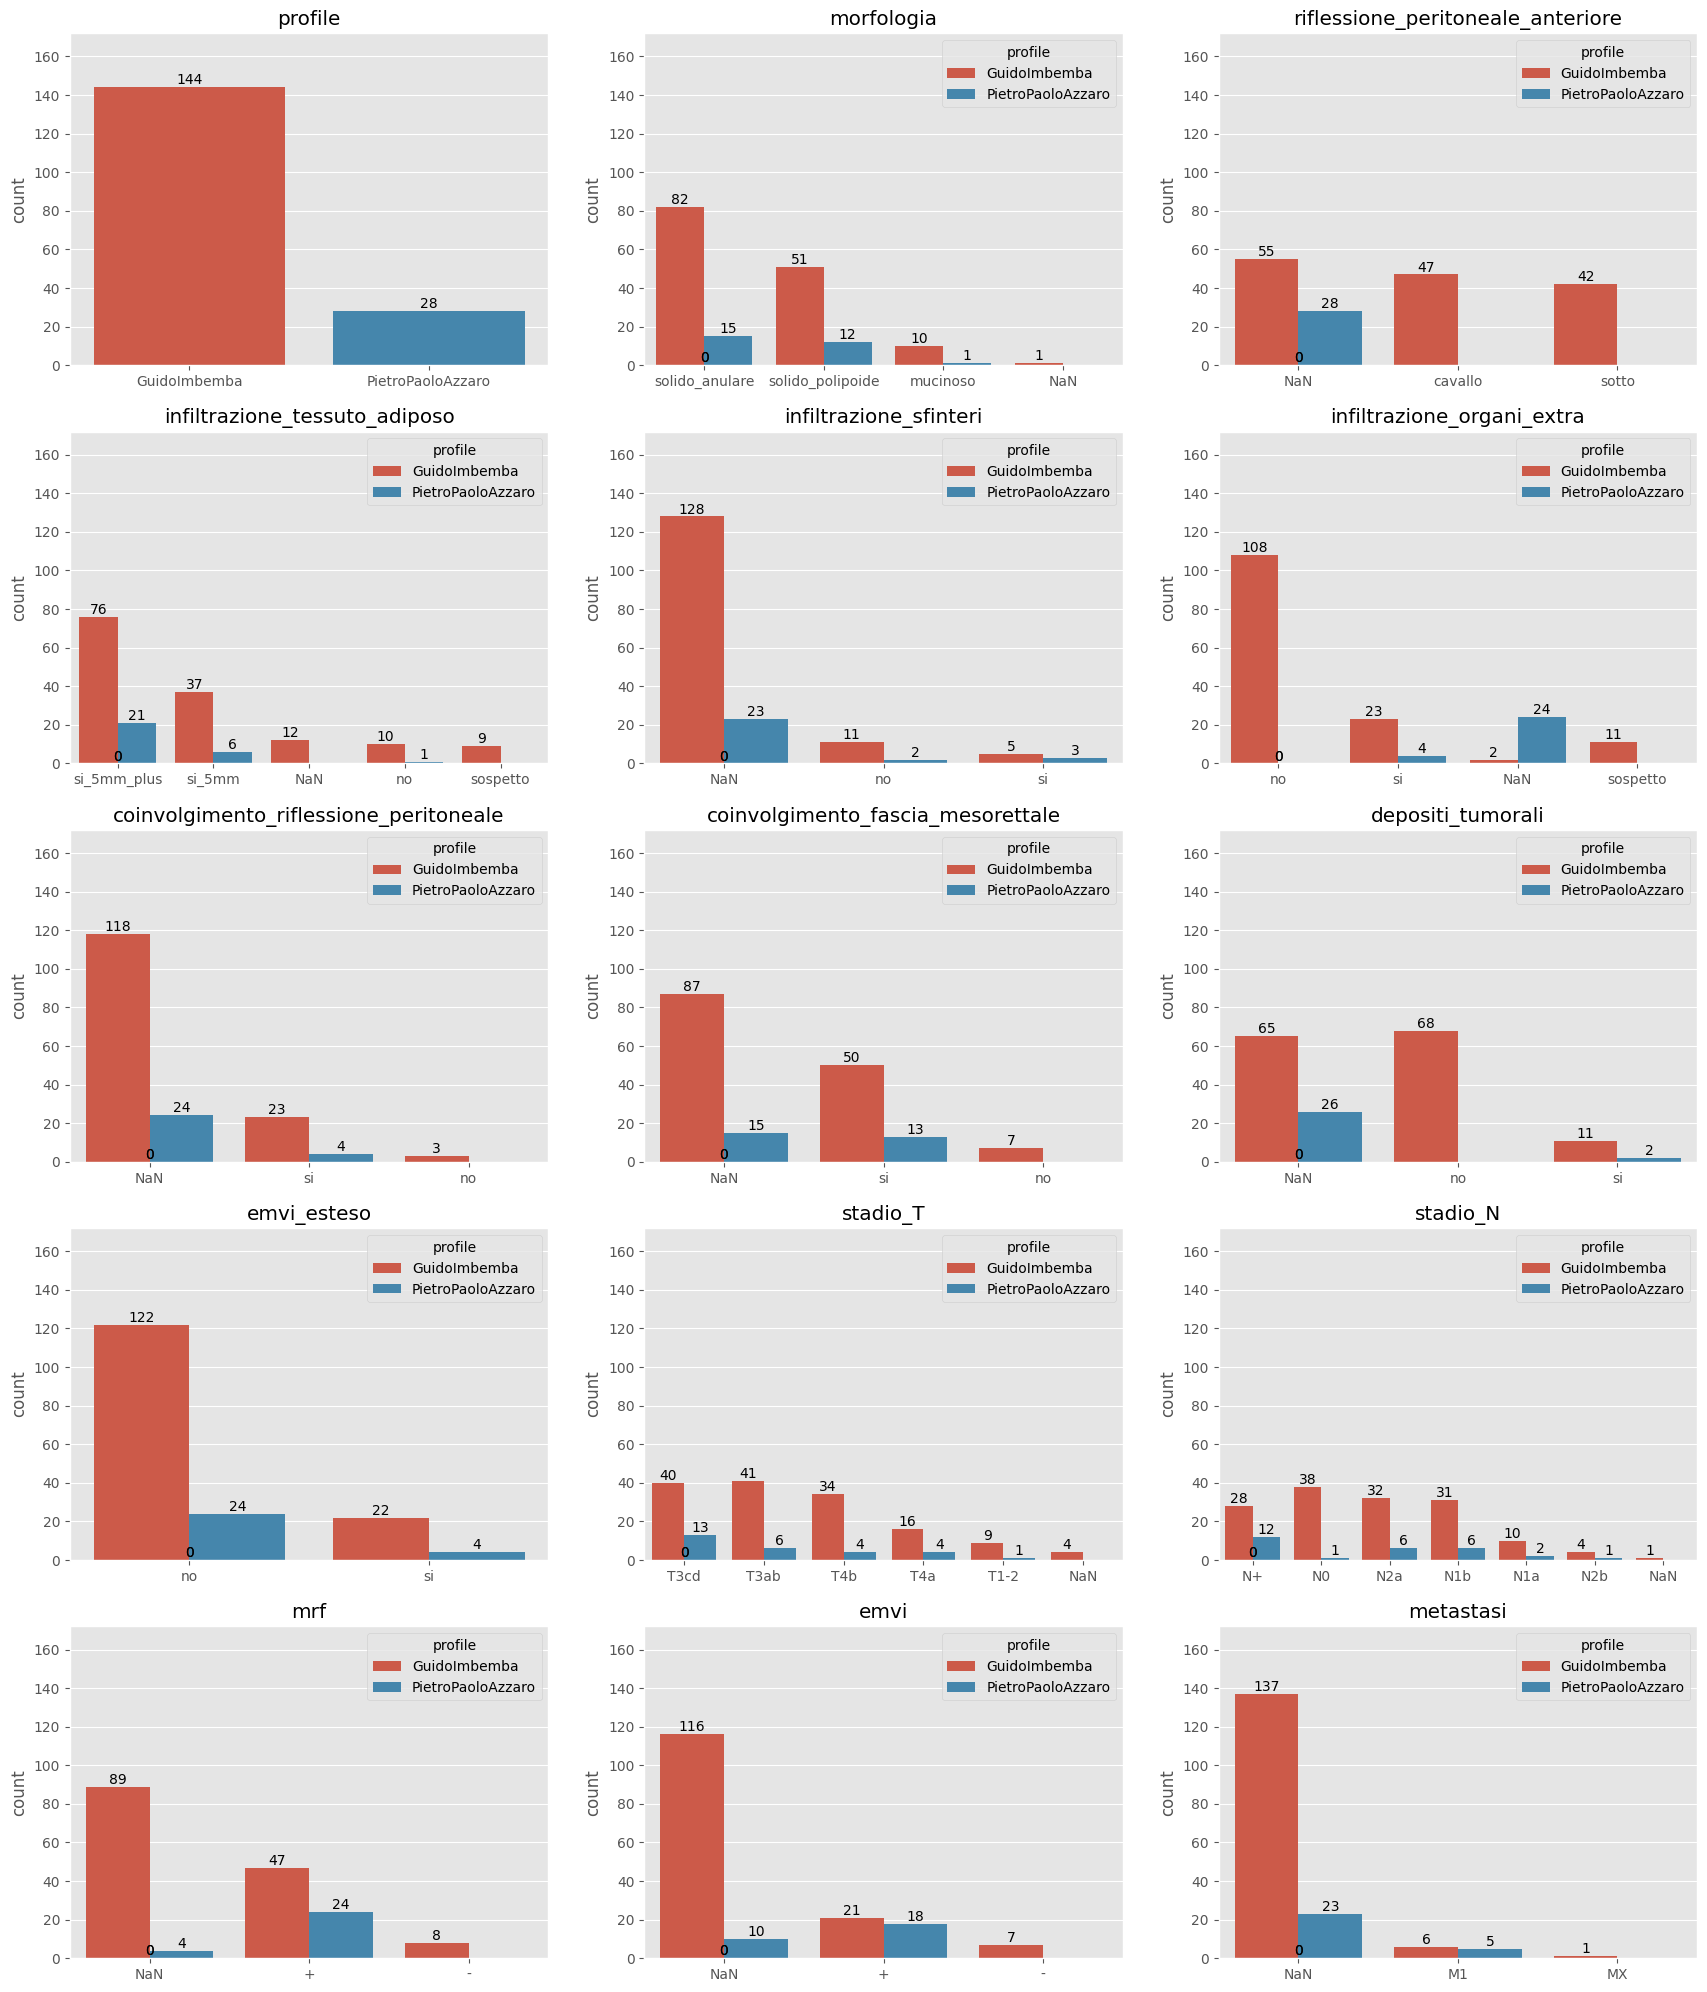

In [9]:
fields = ['profile'] + cl_fields
n_cols = 3
n_rows = math.ceil(len(fields) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
axes = axes.reshape(n_rows, n_cols)

df = []
for i, field in enumerate(fields):
    # PLot counts
    r = i // n_cols
    c = i % n_cols
    ax = axes[r, c]
    sns.countplot(x=field, data=total_data.fillna('NaN'), ax=ax, order=total_data.fillna('NaN')[field].value_counts().index, hue='profile')
    ax.set_title(field)
    ax.set_xlabel("")
    ax.set_ylim(0, total_data.shape[0])
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

for idx in range(len(fields), n_rows*n_cols):
    r = idx // n_cols
    c = idx % n_cols
    axes[r, c].axis("off")

plt.show()